#### IMPORTS

In [1]:
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

from ontology2.classifier_builder.model import build_model
from ontology2.classifier_builder.transformer import Transformer
from config import *
from ontology2.classifier_builder.device import DEVICE

#### CUDA

In [2]:
try:
    print(f'Using: {torch.cuda.get_device_name(DEVICE)}')
except ValueError:
    print(f'Using: CPU')

Using: AMD Radeon RX 6600


### NETWORK INSTANTIATION

In [3]:
from ontology2.classifier_builder.builder import unwrap_words, annotate
from ontology2.classifier_builder.data import PredictionDataset, Tokenizer, Vocabulary, dataset_defaults, tokenizer_defaults, vocabulary_defaults


tokenizer = Tokenizer(**tokenizer_defaults())

with open(f'{RESOURCES}/example_texts_unlabeled.txt', 'r') as f:
    source_texts = f.read().split('\n')

with open(f'{RESOURCES}/example_texts_labeled.txt', 'r') as f:
    target_texts = f.read().split('\n')

vocab = Vocabulary(**vocabulary_defaults())
vocab.new_ws(unwrap_words(source_texts, tokenizer))
vocab.new_ws(unwrap_words(target_texts, tokenizer))
print(f'{vocab.size=}')

ds_defaults = dataset_defaults()
ds_defaults['vocabulary'] = vocab
ds_defaults['tokenizer'] = tokenizer

ds_defaults['train'] = False
p_ds1 = PredictionDataset(**ds_defaults).prepare(source_texts)

parameters = {
    'module': Transformer,
    'module_parameters': {
        'src_vocab_size': vocab.size, 
        'tgt_vocab_size': vocab.size, 
        'max_seq_length': ds_defaults['sequence_len'], 
        'd_model': 1024, 
        'num_heads': 8, 
        'num_layers': 6,
        'dropout': .1, 
        'd_ff': 2048, 
        'nopeak': True,
        'device': DEVICE,
    },
    'optimizer': torch.optim.Adam,
    'optimizer_parameters': {
        'lr':  1e-5,
        'eps': 1e-9,
        'betas': (0.9, 0.95),
    },
    'criterion': nn.CrossEntropyLoss,
    'criterion_parameters': {
        'weight': torch.tensor([
            *[0.0 for _ in range(vocab.n_spec_tokens)],
            *[1.0 for _ in range(vocab.size - vocab.n_spec_tokens)]
        ], device=DEVICE)
    },
    'sep': vocab.w2i('[sep]'),
    'ignore_index': tuple(range(vocab.n_spec_tokens)),
    'name': 'transformer',
    'version': '.1',
}

vocab.size=354


In [4]:
transformer = build_model(f'{RESOURCES}/models/transformer', **parameters)

### TESTS

In [5]:
annotate(transformer, p_ds1)

Любовь зла , как огонь , она сжигает душу и сердце , оставляя лишь пепел и боль .
любовь зла , как огонь , она сжигает душу и сердце , оставляя лишь пепел и боль .

Все говорят , что любовь прекрасна , но я знаю , что любовь зла и безжалостна .
все говорят , что любовь прекрасна , но я знаю , что любовь зла и безжалостна .

Любовь зла , как магнит , притягивающий к себе , но несущий в себе разрушение .
любовь зла , как магнит , притягивающий к себе , но несущий в себе разрушение .

В мире , где царит любовь , неизбежно всплывает и темная сторона – любовь зла .
в мире , где царит любовь , неизбежно всплывает и темная сторона – любовь зла .

Любовь зла , когда сердце наполняется ненавистью , а душа терзается страстью и ревностью .
любовь зла , когда сердце наполняется ненавистью , а душа терзается страстью и ревностью .

Никто не может ускользнуть от власти любви , которая порой превращается в самое настоящее зло .
никто не может ускользнуть от власти любви , которая порой превращается в

### PLOTS

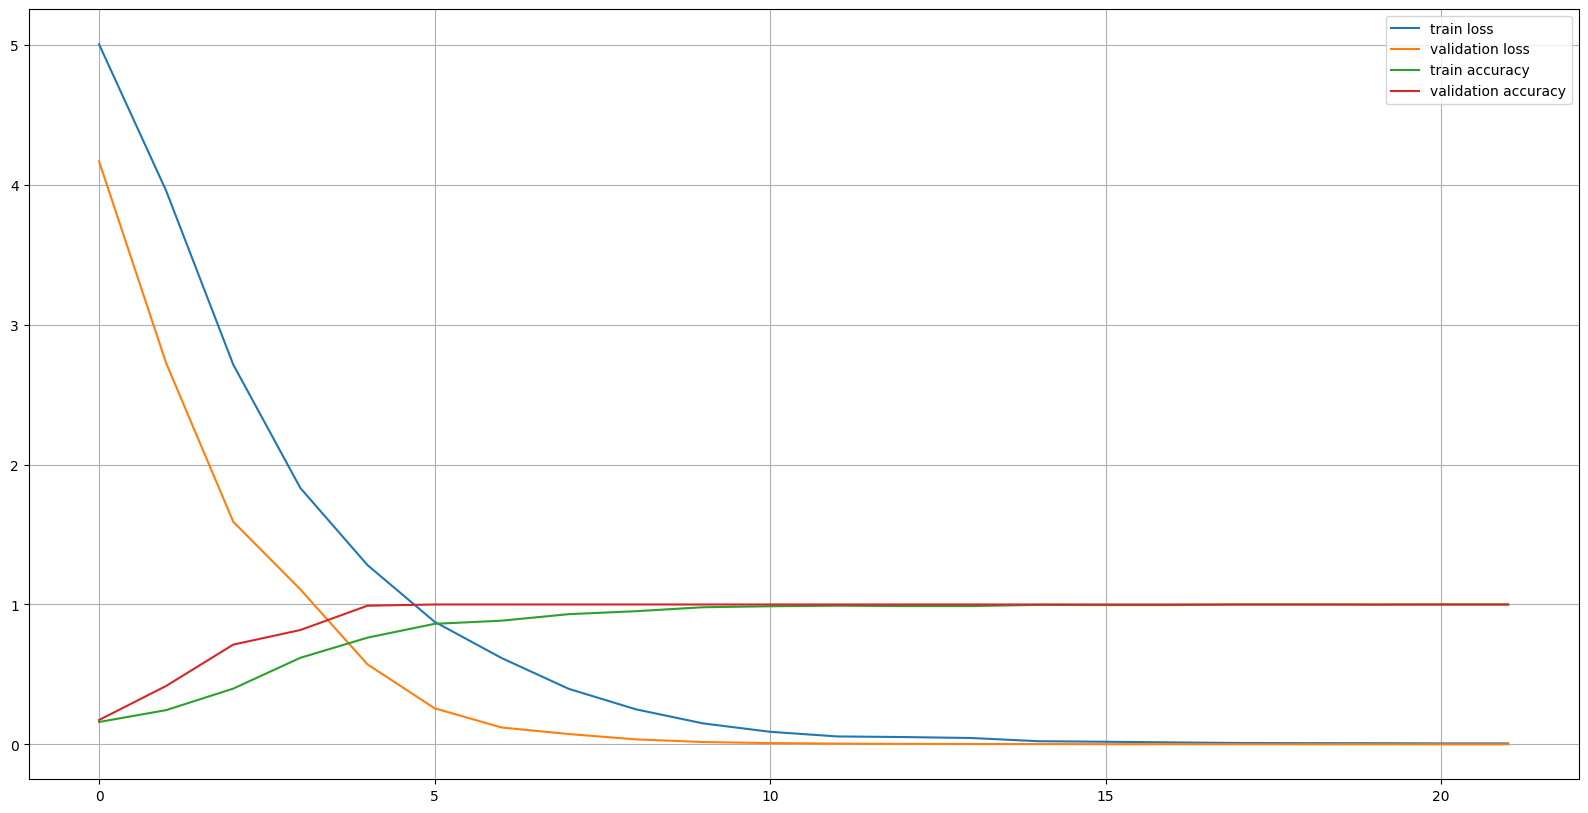

TA=1.0, VA=1.0


In [8]:
stats = transformer.stats_mem

plt.figure(figsize=(20,10))
# plt.ylim([-.05, 1.05])
plt.grid()
plt.plot([s['t_loss'] for s in stats])
plt.plot([s['v_loss'] for s in stats])
plt.plot([s['t_accuracy'] for s in stats])
plt.plot([s['v_accuracy'] for s in stats])
plt.legend(['train loss', 'validation loss', 'train accuracy', 'validation accuracy'])
plt.show()

print(f'TA={stats[-1]["t_accuracy"]}, VA={stats[-1]["v_accuracy"]}')